This file makes plots showing the contributions to radiative forcing grouped by ecoregions and political regions. The dataset come from avergae values assigned to individual fire scars.

In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/Users/hrchapmandutton/Documents/Projects/CDW/fires_2001_2019_single_burn_clip_permaprob.csv')
df.head()

,Join_Count,TARGET_FID,NAME,RECORDNUMB,ACRES,PERIMETERD,SOURCE,SOURCEMETH,SOURCECLAS,AGENCYACRE,...,FrAreaKm,GHG,Permafrost,Albedo,Recovery,NetRF,Country,PermProb,MaxData,PermaData
0,2,0,Boundary River,362,14229.39,9/6/2020 0:00:00,Image Interpretation,,,0.0,...,57.356451,7.927948,1.023267,-9.046753,-0.600374,-0.695913,Alaska,0.858263,yes,yes
1,2,1,Old Grouch Top,174,224907.36,8/18/2020 0:00:00,Image Interpretation,,,0.0,...,843.349839,8.820625,4.172040,-7.255371,-0.644792,5.092502,Alaska,0.446461,yes,yes
2,1,2,Tom Cook Slough,526,7035.06,8/18/2020 0:00:00,Image Interpretation,,,0.0,...,26.779108,9.358701,8.939450,-8.177062,-0.389494,9.731596,Alaska,0.441799,yes,yes
3,1,3,Swan Lake,181,164803.10,7/20/2020 0:00:00,Image Interpretation,,,0.0,...,662.285623,9.223872,0.000000,-8.316302,-0.528114,0.379457,Alaska,0.000006,yes,yes
4,1,4,Long,484,236.35,6/27/2020 0:00:00,Image Interpretation,Image,,0.0,...,0.956487,10.225696,0.018408,-8.017159,-0.620474,1.606471,Alaska,0.004664,yes,yes


In [ ]:
df_filter = df[df['MaxData'] == 'yes']

In [ ]:
cats = ['NA_L1NAME', 'NetRF', 'Recovery', 'Albedo', 'Permafrost', 'GHG']
df_RF = df_filter[cats]
df_RF.head()

,NA_L1NAME,NetRF,Recovery,Albedo,Permafrost,GHG
0,NORTHWESTERN FORESTED MOUNTAINS,-0.695913,-0.600374,-9.046753,1.023267,7.927948
1,TAIGA,5.092502,-0.644792,-7.255371,4.172040,8.820625
2,TAIGA,9.731596,-0.389494,-8.177062,8.939450,9.358701
3,MARINE WEST COAST FOREST,0.379457,-0.528114,-8.316302,0.000000,9.223872
4,NORTHWESTERN FORESTED MOUNTAINS,1.606471,-0.620474,-8.017159,0.018408,10.225696


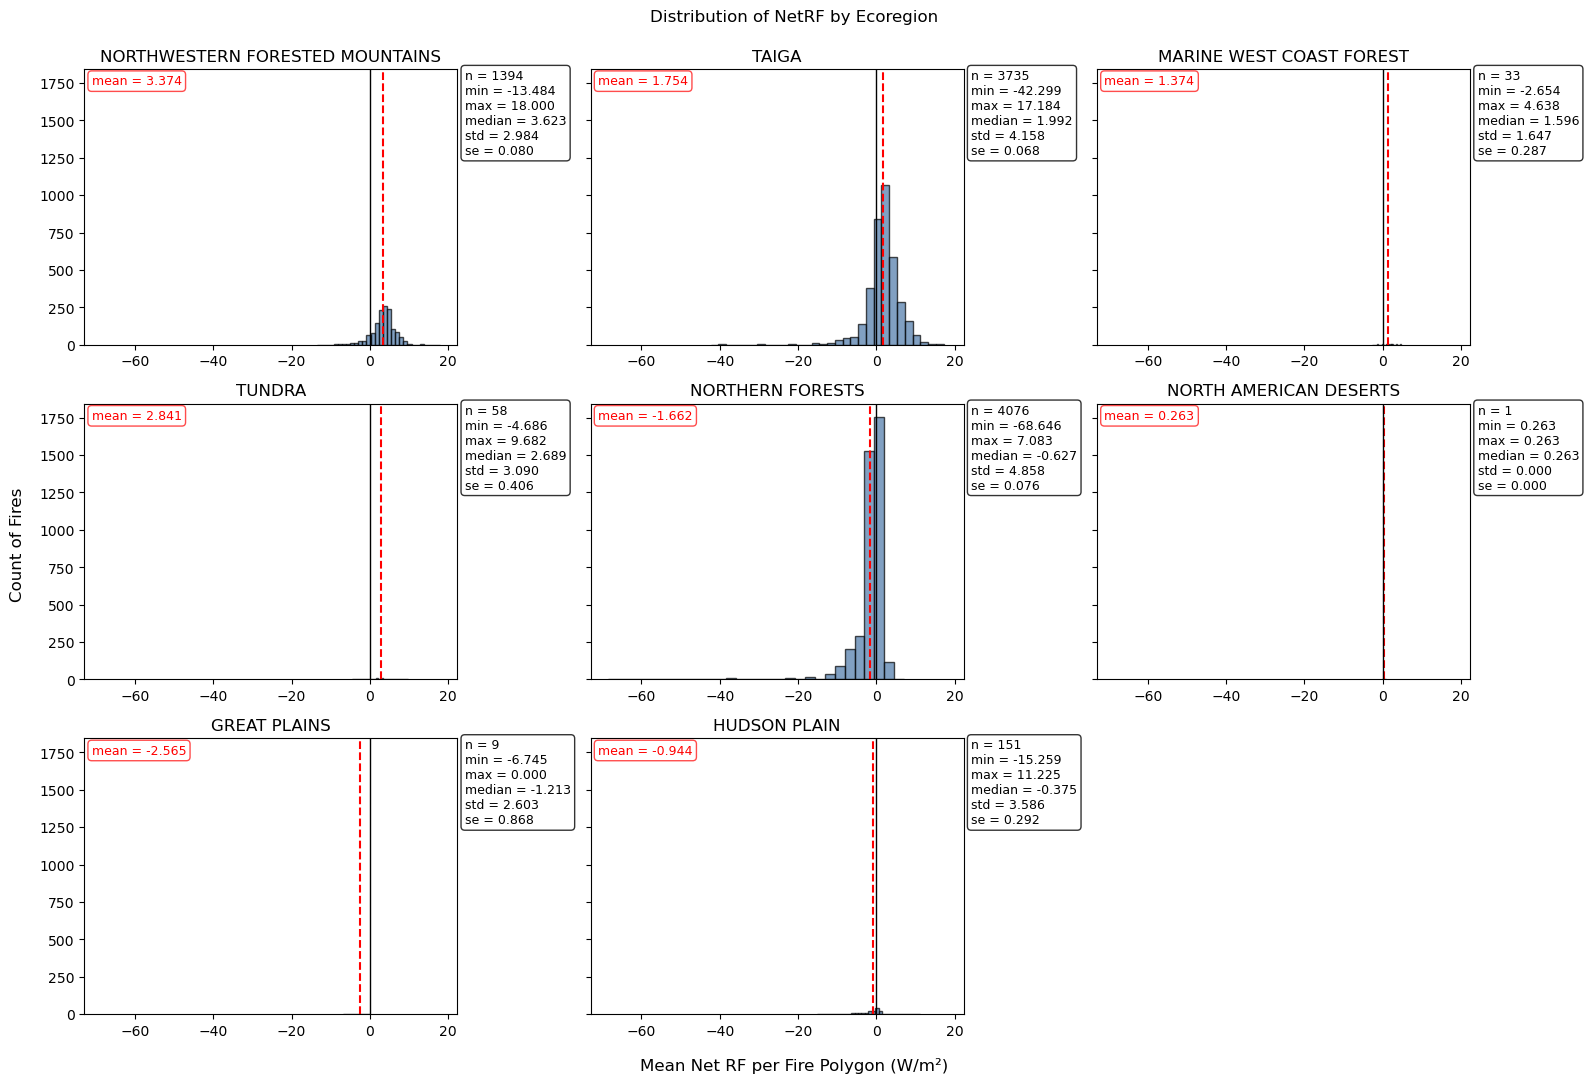

In [41]:
import math
import numpy as np

# Create one histogram panel per ecoregion in df_RF
ecoregions = [eco for eco in df_RF['NA_L1NAME'].dropna().unique() if pd.notna(eco)]
n_regions = len(ecoregions)

fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(16, 3.6 * 3),
    sharex=True,
    sharey=True,
)
axes = np.atleast_1d(axes).ravel()

for ax, eco in zip(axes, ecoregions):
    values = pd.to_numeric(df_RF.loc[df_RF['NA_L1NAME'] == eco, 'NetRF'], errors='coerce').dropna()

    if values.empty:
        ax.axis('off')
        continue

    mean_val = values.mean()
    median_val = values.median()
    std_val = values.std(ddof=1) if len(values) > 1 else 0.0
    sem_val = std_val / np.sqrt(len(values)) if len(values) > 1 else 0.0
    n_fires = len(values)
    min_val = values.min()
    max_val = values.max()

    ax.hist(values, bins=30, color='#4C78A8', edgecolor='black', alpha=0.7)
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5)
    ax.axvline(0, color='black', linestyle='-', linewidth=1)

    stats_text = (
        f"n = {n_fires}\n"
        f"min = {min_val:.3f}\n"
        f"max = {max_val:.3f}\n"
        f"median = {median_val:.3f}\n"
        f"std = {std_val:.3f}\n"
        f"se = {sem_val:.3f}"
    )
    ax.text(
        1.02,
        1.00,
        stats_text,
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
    )

    ax.text(
        0.02,
        0.98,
        f'mean = {mean_val:.3f}',
        transform=ax.transAxes,
        color='red',
        fontsize=9,
        ha='left',
        va='top',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='red', alpha=0.7),
    )

    ax.set_title(eco)
    #ax.set_xlim(left=-20)
    ax.tick_params(labelbottom=True)

for ax in axes[n_regions:]:
    ax.axis('off')

fig.suptitle('Distribution of NetRF by Ecoregion', y=0.995)
fig.supxlabel('Mean Net RF per Fire Polygon (W/m²)', y = 0.01)
fig.supylabel('Count of Fires', x=0.01)
plt.tight_layout()
plt.show()

In [42]:
cats2 = ['Country', 'NetRF', 'Recovery', 'Albedo', 'Permafrost', 'GHG']
df_RF_states = df_filter[cats2]
df_RF_states.head()

,Country,NetRF,Recovery,Albedo,Permafrost,GHG
0,Alaska,-0.695913,-0.600374,-9.046753,1.023267,7.927948
1,Alaska,5.092502,-0.644792,-7.255371,4.172040,8.820625
2,Alaska,9.731596,-0.389494,-8.177062,8.939450,9.358701
3,Alaska,0.379457,-0.528114,-8.316302,0.000000,9.223872
4,Alaska,1.606471,-0.620474,-8.017159,0.018408,10.225696


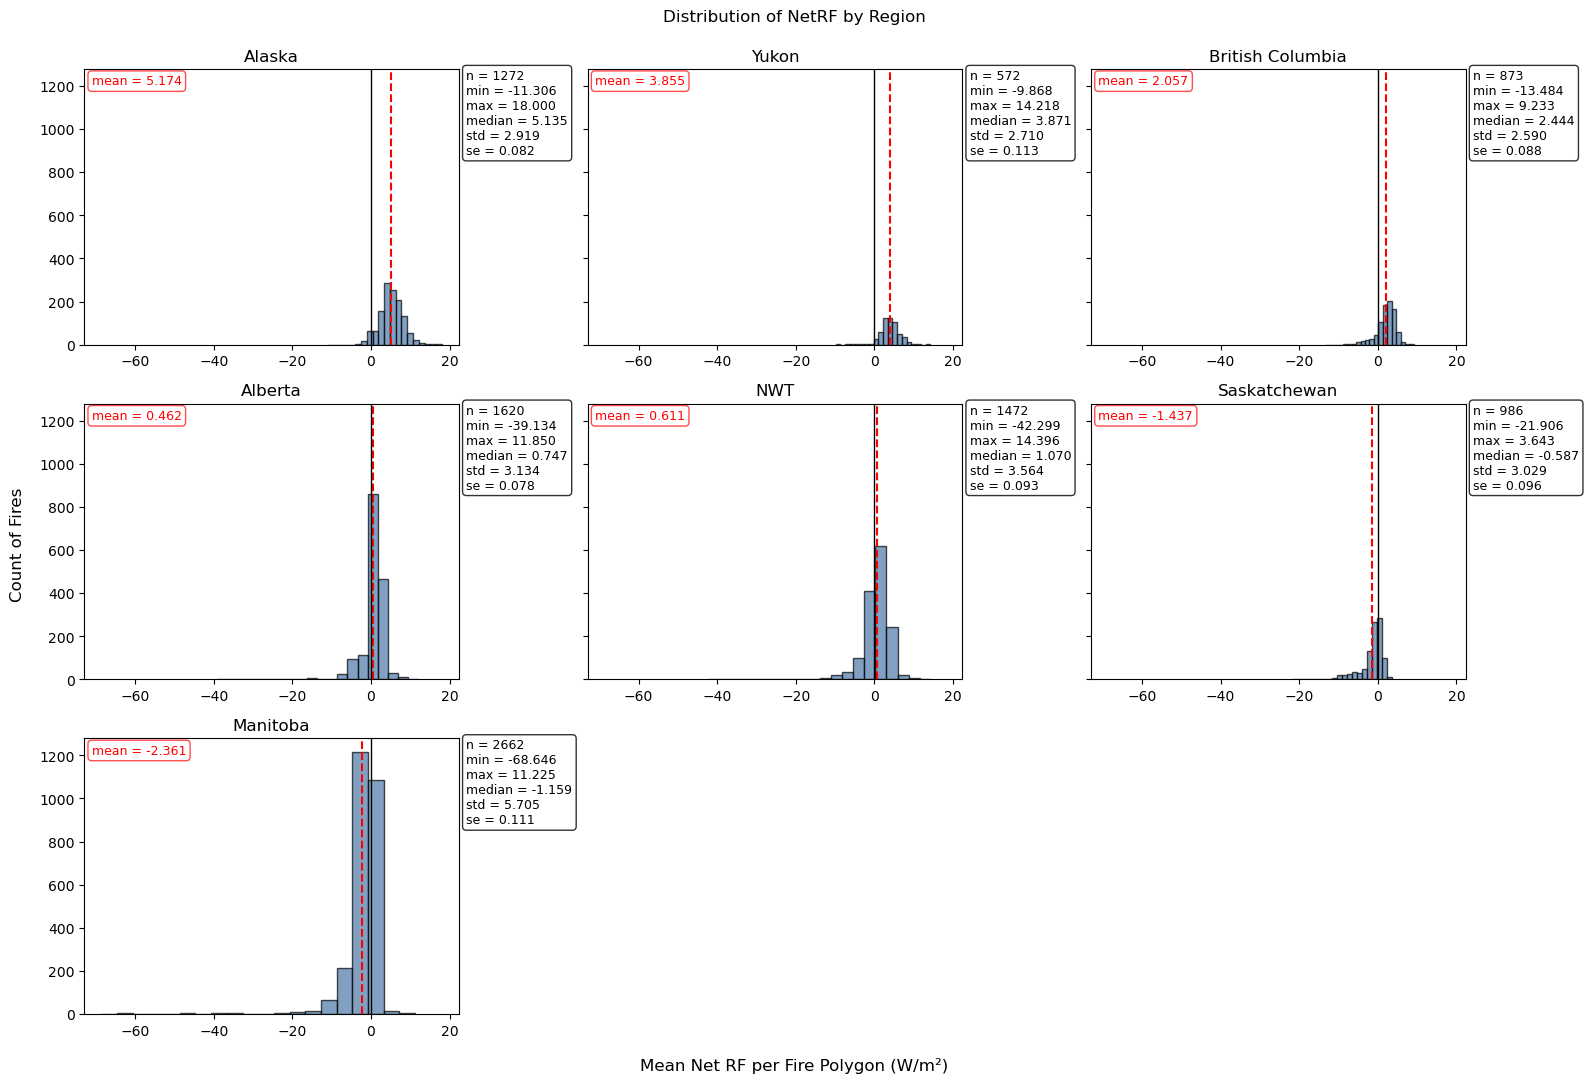

In [43]:
# Create one histogram panel per political region in df_RF
boundaries = [b for b in df_RF_states['Country'].dropna().unique() if pd.notna(b)]
n_regions = len(boundaries)

fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(16, 3.6 * 3),
    sharex=True,
    sharey=True,
)
axes = np.atleast_1d(axes).ravel()

for ax, b in zip(axes, boundaries):
    values = pd.to_numeric(df_RF_states.loc[df_RF_states['Country'] == b, 'NetRF'], errors='coerce').dropna()

    if values.empty:
        ax.axis('off')
        continue

    mean_val = values.mean()
    median_val = values.median()
    std_val = values.std(ddof=1) if len(values) > 1 else 0.0
    sem_val = std_val / np.sqrt(len(values)) if len(values) > 1 else 0.0
    n_fires = len(values)
    min_val = values.min()
    max_val = values.max()

    ax.hist(values, bins=20, color='#4C78A8', edgecolor='black', alpha=0.7)
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5)
    ax.axvline(0, color='black', linestyle='-', linewidth=1)

    stats_text = (
        f"n = {n_fires}\n"
        f"min = {min_val:.3f}\n"
        f"max = {max_val:.3f}\n"
        f"median = {median_val:.3f}\n"
        f"std = {std_val:.3f}\n"
        f"se = {sem_val:.3f}"
    )
    ax.text(
        1.02,
        1.00,
        stats_text,
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
    )

    ax.text(
        0.02,
        0.98,
        f'mean = {mean_val:.3f}',
        transform=ax.transAxes,
        color='red',
        fontsize=9,
        ha='left',
        va='top',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='red', alpha=0.7),
    )

    ax.set_title(b)
    #ax.set_xlim(left=-20)
    ax.tick_params(labelbottom=True)

for ax in axes[n_regions:]:
    ax.axis('off')

fig.suptitle('Distribution of NetRF by Region', y=0.995)
fig.supxlabel('Mean Net RF per Fire Polygon (W/m²)', y = 0.01)
fig.supylabel('Count of Fires', x=0.01)
plt.tight_layout()
plt.show()

In [44]:
eco_sums = df_RF.groupby('NA_L1NAME').sum()
eco_sums = eco_sums.sort_values(by='NetRF', ascending=False)
eco_sums

,NetRF,Recovery,Albedo,Permafrost,GHG
NA_L1NAME,,,,,
TAIGA,6552.578811,-1842.882871,-30633.437823,7664.704399,31364.195111
NORTHWESTERN FORESTED MOUNTAINS,4703.839537,-810.862970,-9154.409600,1602.833043,13066.279052
TUNDRA,164.769841,-14.942491,-598.916158,214.228387,564.400103
MARINE WEST COAST FOREST,45.349624,-17.594498,-220.124133,10.768354,272.299902
NORTH AMERICAN DESERTS,0.263189,-0.539984,-8.311454,0.000000,9.114627
GREAT PLAINS,-23.083550,-7.455006,-67.697723,0.000000,52.069178
HUDSON PLAIN,-142.567059,-72.281347,-1905.228334,502.600858,1332.341761
NORTHERN FORESTS,-6773.550127,-2889.961017,-34890.470774,642.298139,30364.583543


In [45]:
df_long = pd.melt(df_RF, id_vars=['NA_L1NAME'], value_vars=['NetRF', 'Recovery', 'Albedo', 'Permafrost', 'GHG'], var_name='Forcing', value_name='Value')
df_long.rename(columns={'NA_L1NAME': 'Ecoregion'}, inplace=True)
df_long['sign'] = df_long['Value'] >= 0
df_long.head()

,Ecoregion,Forcing,Value,sign
0,NORTHWESTERN FORESTED MOUNTAINS,NetRF,-0.695913,False
1,TAIGA,NetRF,5.092502,True
2,TAIGA,NetRF,9.731596,True
3,MARINE WEST COAST FOREST,NetRF,0.379457,True
4,NORTHWESTERN FORESTED MOUNTAINS,NetRF,1.606471,True


In [ ]:
##soemthing is wrong with this--don't use

g = sns.catplot(data=df_long, x='Value', y='Forcing', row='Ecoregion', kind='box', hue="sign", palette={True: "salmon", False: "cornflowerblue"}, height=3, aspect=2, legend=False, sharex=True)
g.set(ylabel=None)
g.set(xlabel=None)
plt.show()

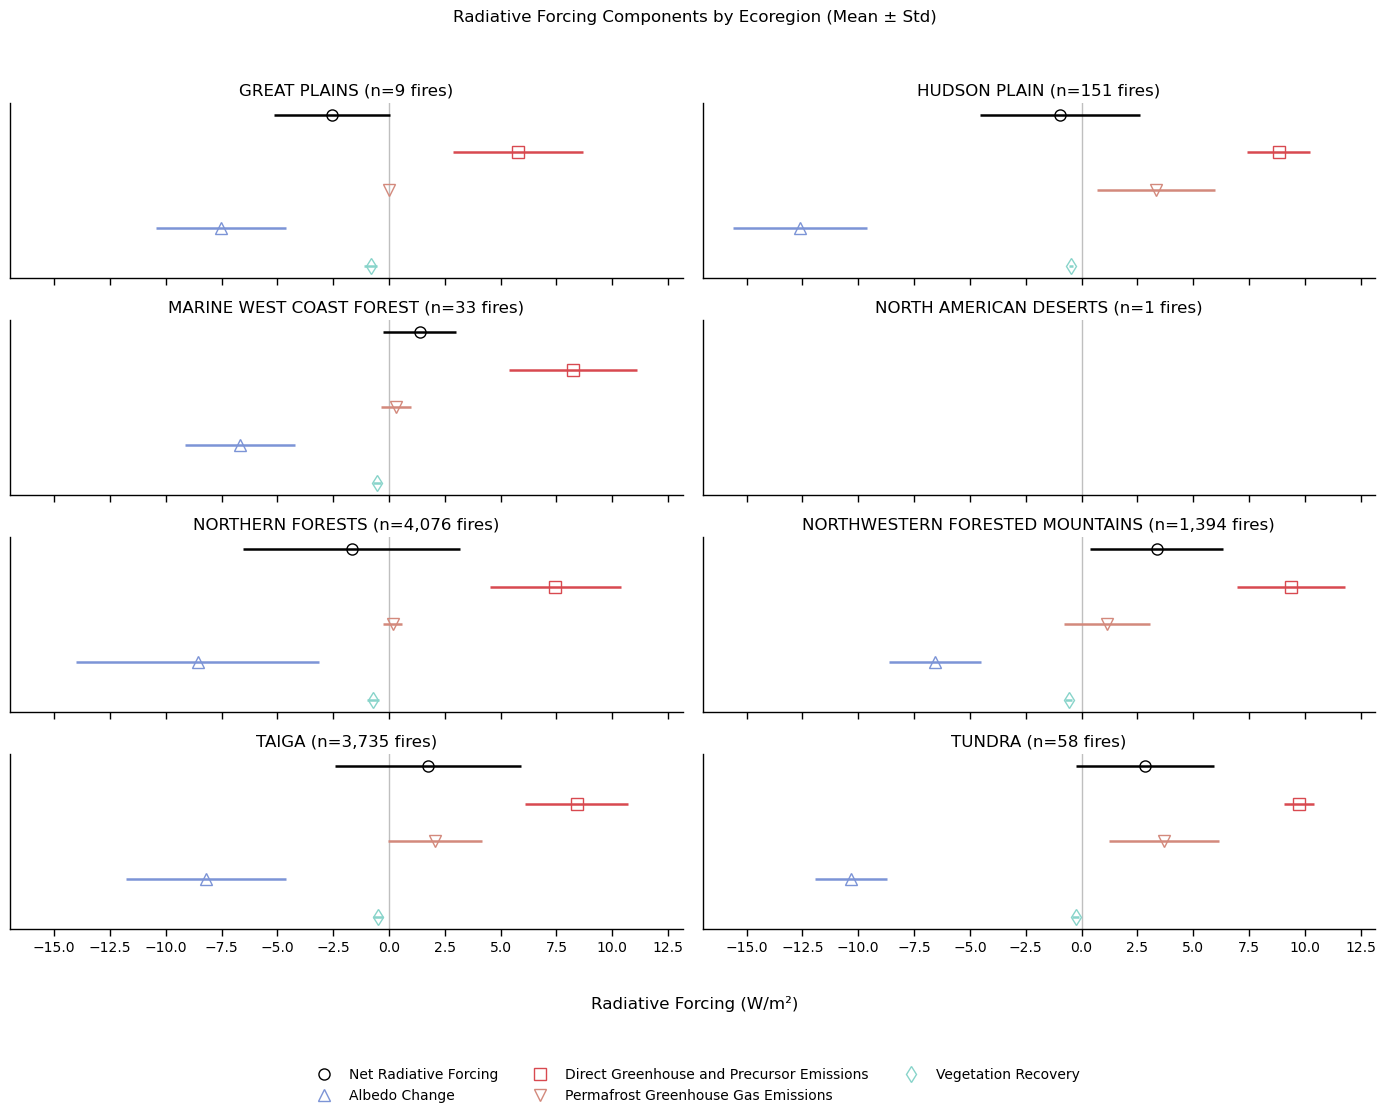

,Ecoregion,Forcing,mean,std,n
0,GREAT PLAINS,Recovery,-0.828334,0.311168,9
1,GREAT PLAINS,Albedo,-7.521969,2.908726,9
2,GREAT PLAINS,Permafrost,0.000000,0.000000,9
3,GREAT PLAINS,GHG,5.785464,2.911134,9
4,GREAT PLAINS,NetRF,-2.564839,2.602980,9
5,HUDSON PLAIN,Recovery,-0.478684,0.095366,151
6,HUDSON PLAIN,Albedo,-12.617406,2.988145,151
7,HUDSON PLAIN,Permafrost,3.328483,2.652211,151
8,HUDSON PLAIN,GHG,8.823455,1.411248,151
9,HUDSON PLAIN,NetRF,-0.944153,3.585621,151


In [46]:
# Mean +/- std plots by ecoregion (same style as the first analysis notebook figure)
import math
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator

# Required columns in df_RF
component_cols = ['Recovery', 'Albedo', 'Permafrost', 'GHG', 'NetRF']

# Build summary stats: one row per ecoregion x forcing component
eco_stats_df = (
    df_RF.groupby('NA_L1NAME')[component_cols]
    .agg(['mean', 'std', 'count'])
    .stack(level=0, future_stack=True)
    .reset_index()
    .rename(columns={
        'NA_L1NAME': 'Ecoregion',
        'level_1': 'Forcing',
        'mean': 'mean',
        'std': 'std',
        'count': 'n'
    })
)

# Order ecoregions by NetRF mean so the panels are easier to scan
eco_order = eco_stats_df['Ecoregion'].unique().tolist()

# Keep forcing order and style consistent across panels
forcing_order = component_cols
style_map = {
    'NetRF': {'color': '#000000', 'marker': 'o', 'label': 'Net Radiative Forcing'},
    'Albedo': {'color': '#7c94d6', 'marker': '^', 'label': 'Albedo Change'},
    'GHG': {'color': '#d84950', 'marker': 's', 'label': 'Direct Greenhouse and Precursor Emissions'},
    'Permafrost': {'color': '#d3897c', 'marker': 'v', 'label': 'Permafrost Greenhouse Gas Emissions'},
    'Recovery': {'color': '#88d4ca', 'marker': 'd', 'label': 'Vegetation Recovery'}
}

# Plot small multiples: one subplot per ecoregion
n_regions = len(eco_order)
ncols = 2 if n_regions > 1 else 1
nrows = math.ceil(n_regions / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(14, 2.8 * nrows),
    sharex=True
)
axes = np.atleast_1d(axes).ravel()

y_step = 0.16
y_pad = 0.05

for ax, eco in zip(axes, eco_order):
    sub = eco_stats_df[eco_stats_df['Ecoregion'] == eco].copy()
    sub['Forcing'] = pd.Categorical(sub['Forcing'], categories=forcing_order, ordered=True)
    sub = sub.sort_values('Forcing').reset_index(drop=True)

    for i, row in sub.iterrows():
        style = style_map[row['Forcing']]
        y_pos = i * y_step
        if np.isfinite(row['mean']) and np.isfinite(row['std']):
            ax.errorbar(
                row['mean'],
                y_pos,
                xerr=row['std'],
                fmt=style['marker'],
                markersize=8,
                markerfacecolor='none',
                markeredgecolor=style['color'],
                color=style['color'],
                ecolor=style['color'],
                elinewidth=1.8,
                capsize=0,
                linestyle='none'
            )

    n_net = int(sub.loc[sub['Forcing'] == 'NetRF', 'n'].iloc[0]) if not sub.empty else 0
    ax.set_title(f"{eco} (n={n_net:,} fires)")
    ax.set_yticks([])
    ax.set_ylim(-y_pad, (len(forcing_order) - 1) * y_step + y_pad)
    ax.grid(False)
    ax.axvline(0, color='gray', linewidth=1, alpha=0.5, zorder=0)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['left'].set_linewidth(1.0)
    ax.xaxis.set_major_locator(MultipleLocator(2.5))
    ax.tick_params(
        axis='x',
        which='major',
        direction='out',
        bottom=True,
        top=False,
        length=5,
        width=1.0,
        colors='black'
    )

# Hide unused axes if grid is larger than number of ecoregions
for ax in axes[n_regions:]:
    ax.axis('off')

legend_handles = [
    Line2D(
        [0], [0],
        marker=style['marker'],
        color='none',
        markeredgecolor=style['color'],
        markerfacecolor='none',
        markersize=8,
        linestyle='none',
        label=style['label']
    )
    for style in style_map.values()
 ]

fig.legend(
    handles=legend_handles,
    frameon=False,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.008),
    ncol=3
)

fig.suptitle('Radiative Forcing Components by Ecoregion (Mean ± Std)', y=0.995)
fig.supxlabel('Radiative Forcing (W/m²)', y=0.1)
plt.tight_layout(rect=[0, 0.11, 1, 0.97])
plt.show()

# Optional preview of summary table
eco_stats_df.head(15)

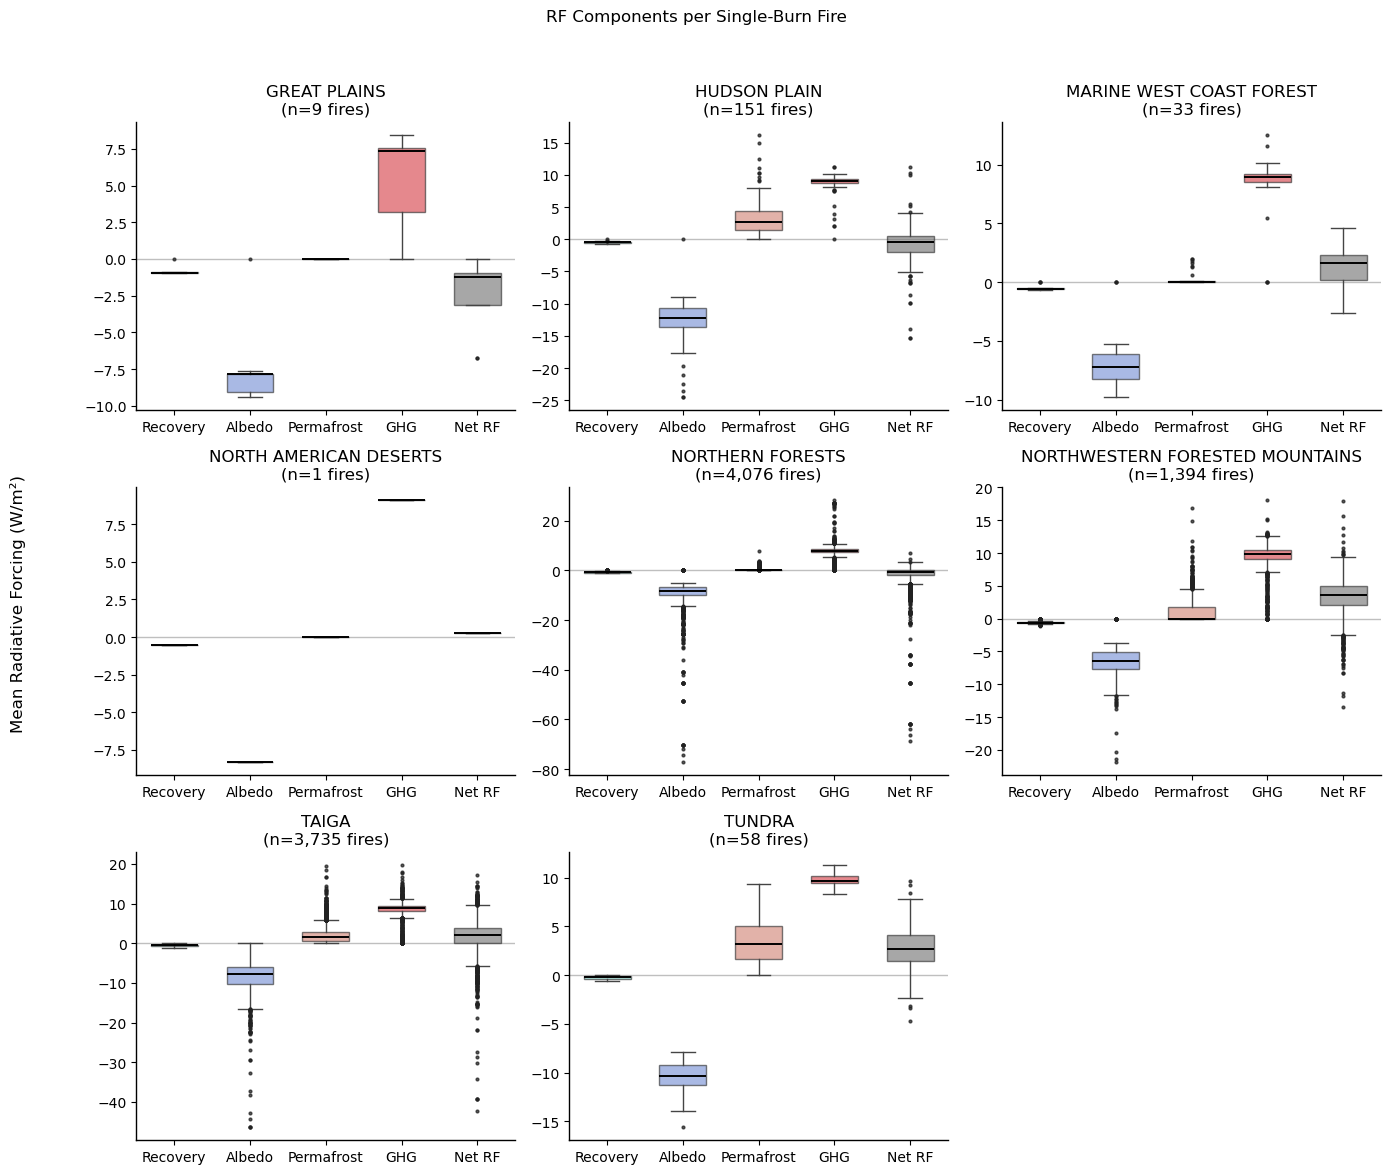

In [52]:
# Boxplot version (uses quartiles/median from raw df_RF values)
# must run previous cell first to define df_RF, eco_order, forcing_order, and style_map

# Toggle: False plots only non-zero values so zero-inflated groups do not collapse to a line at 0
include_zeros = True

n_regions = len(eco_order)
ncols = 3 if n_regions > 2 else 2
nrows = math.ceil(n_regions / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(14, 4 * nrows),
    sharex=True,
    sharey=False
)
axes = np.atleast_1d(axes).ravel()

for ax, eco in zip(axes, eco_order):
    sub_df = df_RF[df_RF['NA_L1NAME'] == eco]

    # Build one array per forcing from raw values; boxplot computes quartiles/whiskers itself
    box_data = []
    for col in forcing_order:
        vals = pd.to_numeric(sub_df[col], errors='coerce').dropna()
        if not include_zeros:
            vals = vals[vals != 0]
        box_data.append(vals.to_numpy(dtype=float))

    # Skip empty panels safely
    if all(arr.size == 0 for arr in box_data):
        ax.axis('off')
        continue

    x = np.arange(len(forcing_order)) + 1
    bplot = ax.boxplot(
        box_data,
        vert=True,
        positions=x,
        widths=0.62,
        patch_artist=True,
        showfliers=True,
        medianprops={'color': 'black', 'linewidth': 1.4},
        whiskerprops={'color': '#444444', 'linewidth': 1.0},
        capprops={'color': '#444444', 'linewidth': 1.0},
        boxprops={'linewidth': 1.0, 'edgecolor': '#333333'},
        flierprops={
            'marker': '.',
            'markerfacecolor': '#222222',
            'markeredgecolor': '#222222',
            'markersize': 4,
            'alpha': 0.75
        }
    )

    for patch, forcing in zip(bplot['boxes'], forcing_order):
        patch.set_facecolor(style_map[forcing]['color'])
        patch.set_alpha(0.65)

    short_labels = {
        'Recovery': 'Recovery',
        'Albedo': 'Albedo',
        'Permafrost': 'Permafrost',
        'GHG': 'GHG',
        'NetRF': 'Net RF'
    }
    labels = [short_labels.get(f, f) for f in forcing_order]
    ax.set_xticks(x)
    ax.set_xticklabels(labels, ha='center', fontsize=10)
    ax.tick_params(axis='x', labelbottom=True)

    n_fires = int(len(sub_df))
    ax.set_title(f"{eco}\n(n={n_fires:,} fires)")

    ax.axhline(0, color='gray', linewidth=1, alpha=0.5, zorder=0)
    ax.grid(False)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['left'].set_linewidth(1.0)

# Hide unused axes if grid is larger than number of ecoregions
for ax in axes[n_regions:]:
    ax.axis('off')

fig.suptitle('RF Components per Single-Burn Fire', y=0.995)
fig.supylabel('Mean Radiative Forcing (W/m²)', x=0.01)
plt.tight_layout(rect=[0.03, 0.02, 1, 0.97])
plt.show()

/var/folders/sq/yw612wzn25s9n4pclwvt88m40000gq/T/ipykernel_9011/1016313368.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/sq/yw612wzn25s9n4pclwvt88m40000gq/T/ipykernel_9011/1016313368.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([short_labels.get(f, f) for f in forcing_order], ha='center', fontsize=10)
/var/folders/sq/yw612wzn25s9n4pclwvt88m40000gq/T/ipykernel_9011/1016313368.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/sq/yw612wzn25s9n4pclwvt88m40000gq/T/ipykernel_9011/1016313368.py:64: UserWarning: set_ticklabels() should only be u

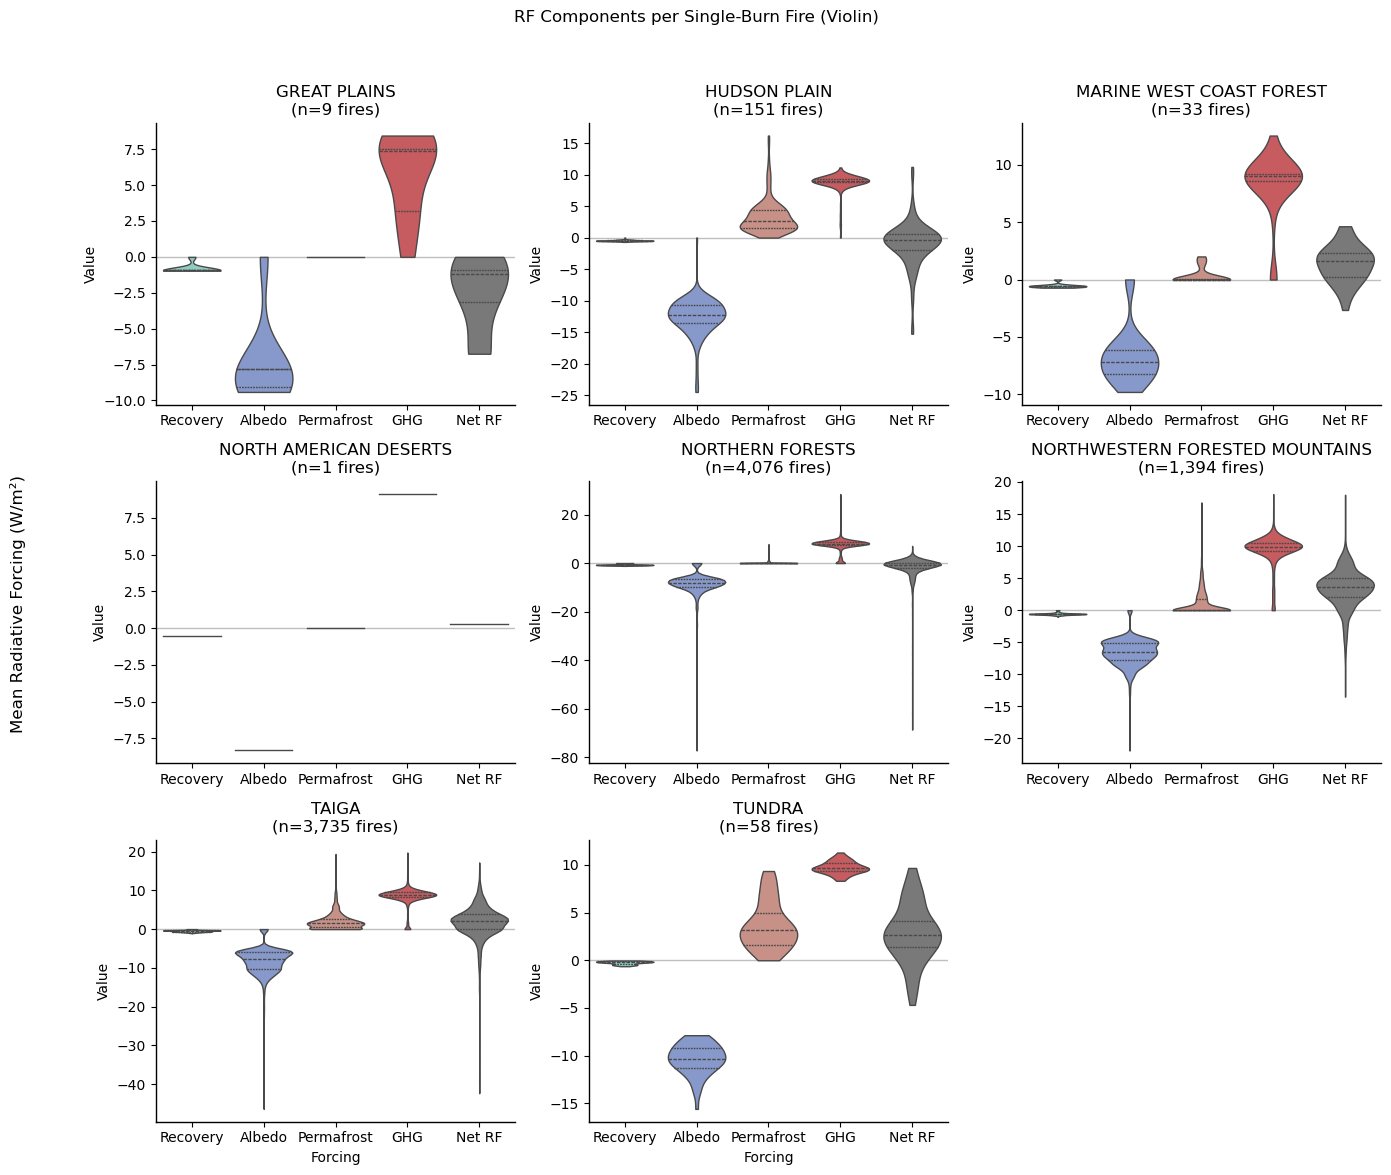

In [51]:
# Violin version of the same per-ecoregion subplot design
# must run previous cell first to define df_RF, eco_order, forcing_order, and style_map

include_zeros = True

n_regions = len(eco_order)
ncols = 3 if n_regions > 2 else 2
nrows = math.ceil(n_regions / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(14, 4 * nrows),
    sharex=True,
    sharey=False
)
axes = np.atleast_1d(axes).ravel()

short_labels = {
    'Recovery': 'Recovery',
    'Albedo': 'Albedo',
    'Permafrost': 'Permafrost',
    'GHG': 'GHG',
    'NetRF': 'Net RF'
}
style_map = {
    'NetRF': {'color': "#797979", 'marker': 'o', 'label': 'Net Radiative Forcing'},
    'Albedo': {'color': '#7c94d6', 'marker': '^', 'label': 'Albedo Change'},
    'GHG': {'color': '#d84950', 'marker': 's', 'label': 'Direct Greenhouse and Precursor Emissions'},
    'Permafrost': {'color': '#d3897c', 'marker': 'v', 'label': 'Permafrost Greenhouse Gas Emissions'},
    'Recovery': {'color': '#88d4ca', 'marker': 'd', 'label': 'Vegetation Recovery'}
}
palette_map = {f: style_map[f]['color'] for f in forcing_order}

for ax, eco in zip(axes, eco_order):
    sub_df = df_RF[df_RF['NA_L1NAME'] == eco]

    plot_rows = []
    for forcing in forcing_order:
        vals = pd.to_numeric(sub_df[forcing], errors='coerce').dropna()
        if not include_zeros:
            vals = vals[vals != 0]
        if vals.size:
            plot_rows.append(pd.DataFrame({'Forcing': forcing, 'Value': vals.values}))

    if not plot_rows:
        ax.axis('off')
        continue

    plot_df = pd.concat(plot_rows, ignore_index=True)

    sns.violinplot(
        data=plot_df,
        x='Forcing',
        y='Value',
        order=forcing_order,
        palette=palette_map,
        cut=0,
        inner='quartile',
        linewidth=1,
        ax=ax
    )

    ax.set_xticklabels([short_labels.get(f, f) for f in forcing_order], ha='center', fontsize=10)
    ax.tick_params(axis='x', labelbottom=True)

    n_fires = int(len(sub_df))
    ax.set_title(f"{eco}\n(n={n_fires:,} fires)")
    ax.axhline(0, color='gray', linewidth=1, alpha=0.5, zorder=0)
    ax.grid(False)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['left'].set_linewidth(1.0)

for ax in axes[n_regions:]:
    ax.axis('off')

fig.suptitle('RF Components per Single-Burn Fire (Violin)', y=0.995)
fig.supylabel('Mean Radiative Forcing (W/m²)', x=0.01)
plt.tight_layout(rect=[0.03, 0.02, 1, 0.97])
plt.show()

In [54]:
cats3 = ['NA_L1NAME', 'NetRF', 'PermProb']
filt = df_filter[df_filter['PermProb'] > -9999]
df_perma = filt[cats3]
df_perma.head()

,NA_L1NAME,NetRF,PermProb
0,NORTHWESTERN FORESTED MOUNTAINS,-0.695913,0.858263
1,TAIGA,5.092502,0.446461
2,TAIGA,9.731596,0.441799
3,MARINE WEST COAST FOREST,0.379457,0.000006
4,NORTHWESTERN FORESTED MOUNTAINS,1.606471,0.004664


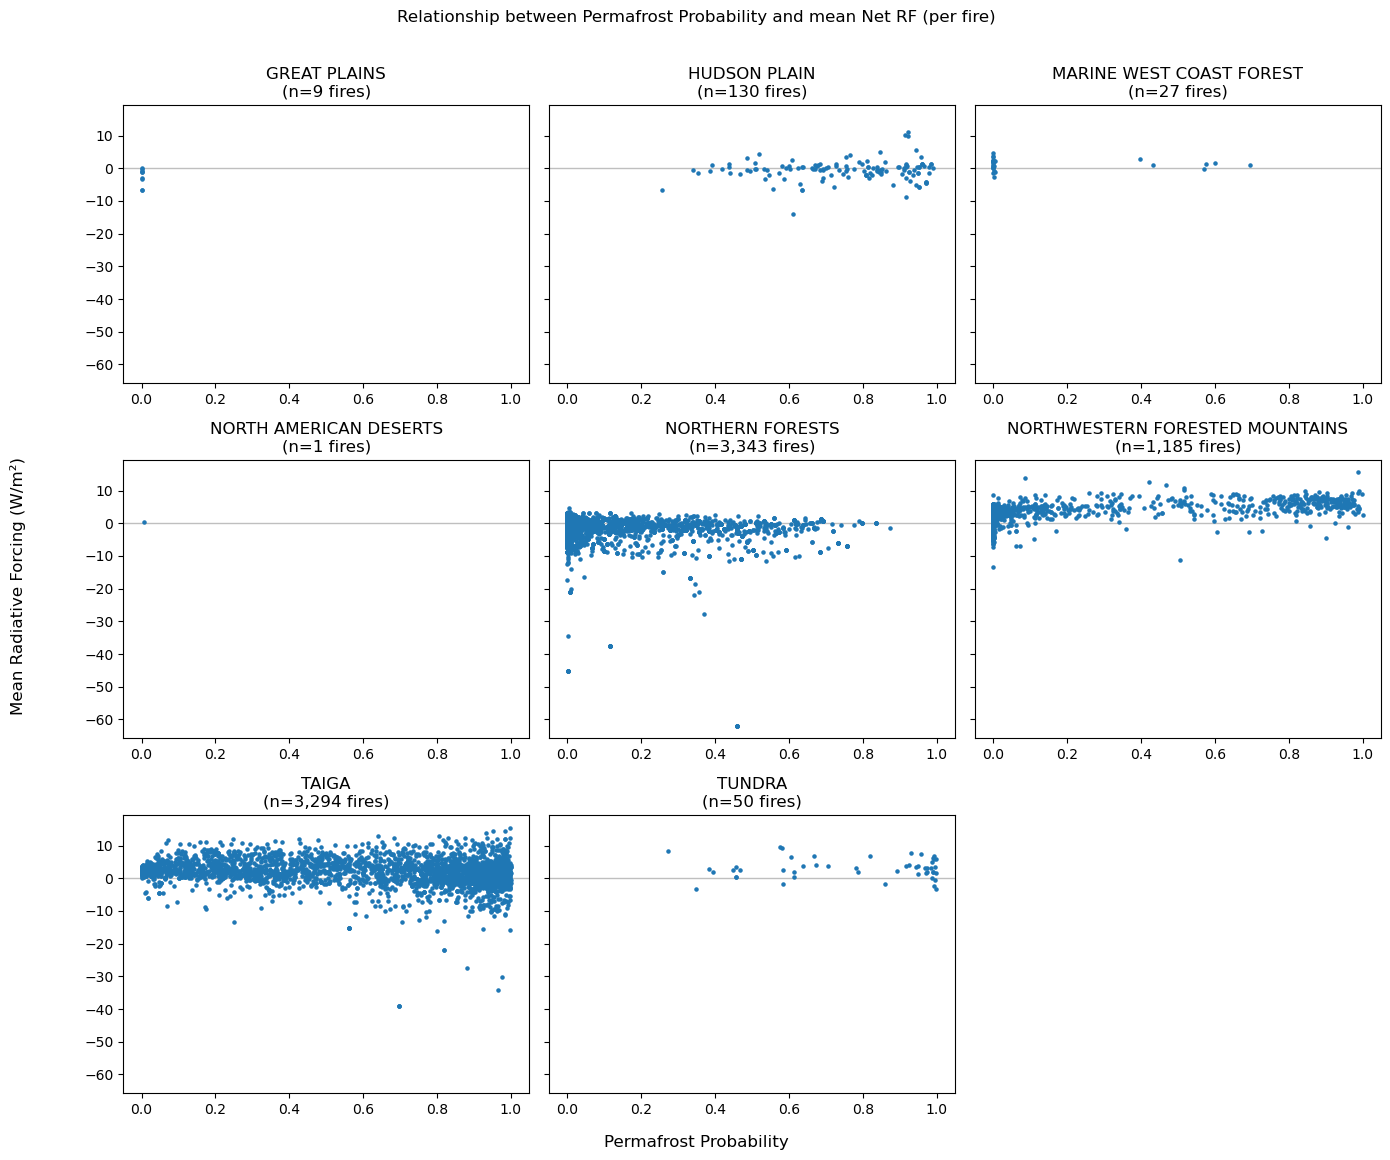

In [62]:
include_zeros = True

n_regions = len(eco_order)
ncols = 3 if n_regions > 2 else 2
nrows = math.ceil(n_regions / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(14, 4 * nrows),
    sharex=True,
    sharey=True
)
axes = np.atleast_1d(axes).ravel()

for ax, eco in zip(axes, eco_order):
    sub_df = df_perma[df_perma['NA_L1NAME'] == eco]

    x = np.arange(len(forcing_order)) + 1
    scat = ax.scatter(
        sub_df['PermProb'],
        sub_df['NetRF'],
        s=5
    )

    ax.tick_params(axis='x', labelbottom=True)

    n_fires = int(len(sub_df))
    ax.set_title(f"{eco}\n(n={n_fires:,} fires)")

    ax.axhline(0, color='gray', linewidth=1, alpha=0.5, zorder=0)
    ax.grid(False)

# Hide unused axes if grid is larger than number of ecoregions
for ax in axes[n_regions:]:
    ax.axis('off')

fig.suptitle('Relationship between Permafrost Probability and mean Net RF (per fire)', y=0.98)
fig.supylabel('Mean Radiative Forcing (W/m²)', x=0.01)
fig.supxlabel('Permafrost Probability', y=0.03)
plt.tight_layout(rect=[0.03, 0.02, 1, 0.97])
plt.show()

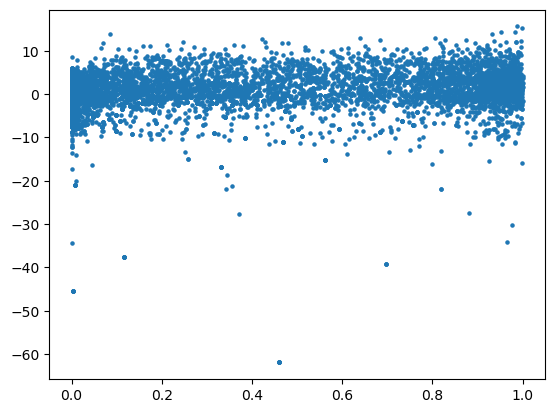

In [63]:
plt.scatter(df_perma['PermProb'], df_perma['NetRF'], s=5)
plt.show()
